# NARX model

Nonlinear AutoRegressive with eXogenous inputs (NARX) model identified from the `multisine_05` experiment of the Ball-and-Beam (BAB) dataset, using Forward Regression Orthogonal Least Squares (FROLS) for term selection.

## 1. Install dependencies and imports

In [1]:
!pip install git+https://github.com/helonayala/bab_datasets.git -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import bab_datasets as nod

# Install/import the sysid course library (works locally and on Google Colab)
try:
    from sysid import NARX
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import NARX


## 2. Load dataset

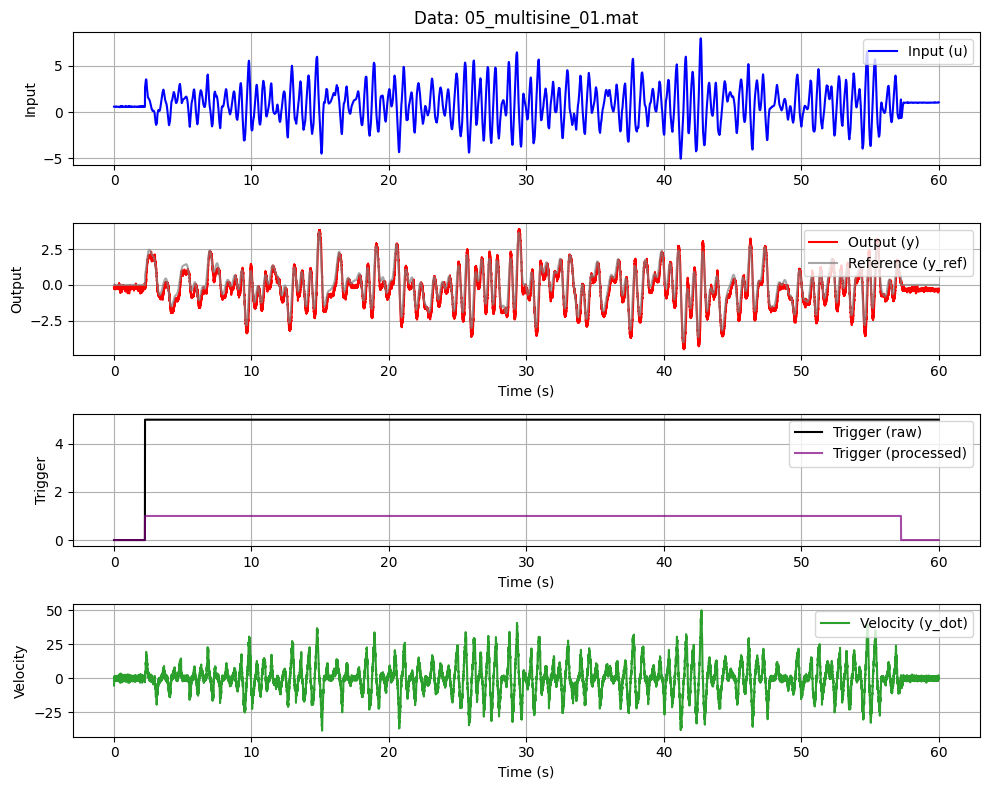

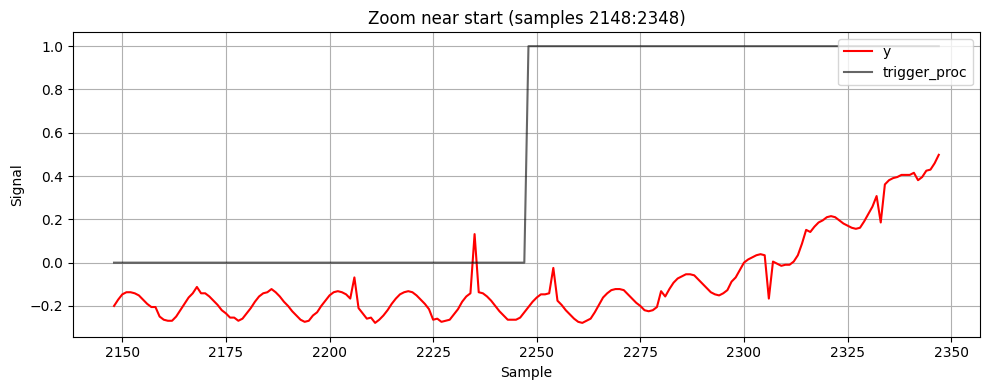

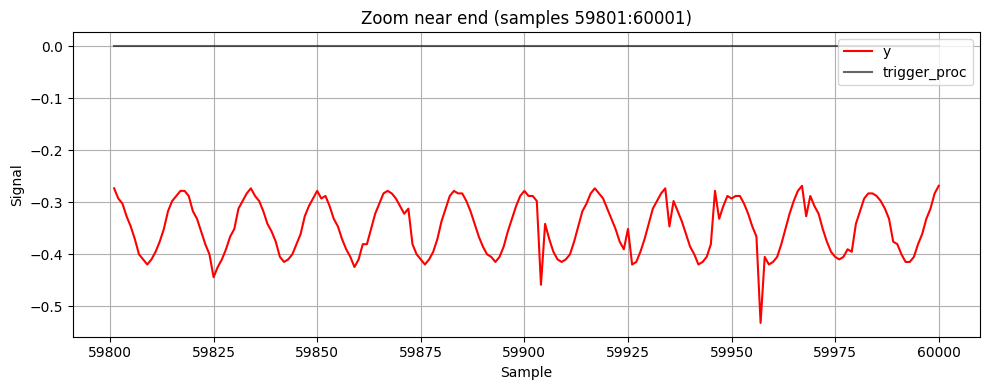

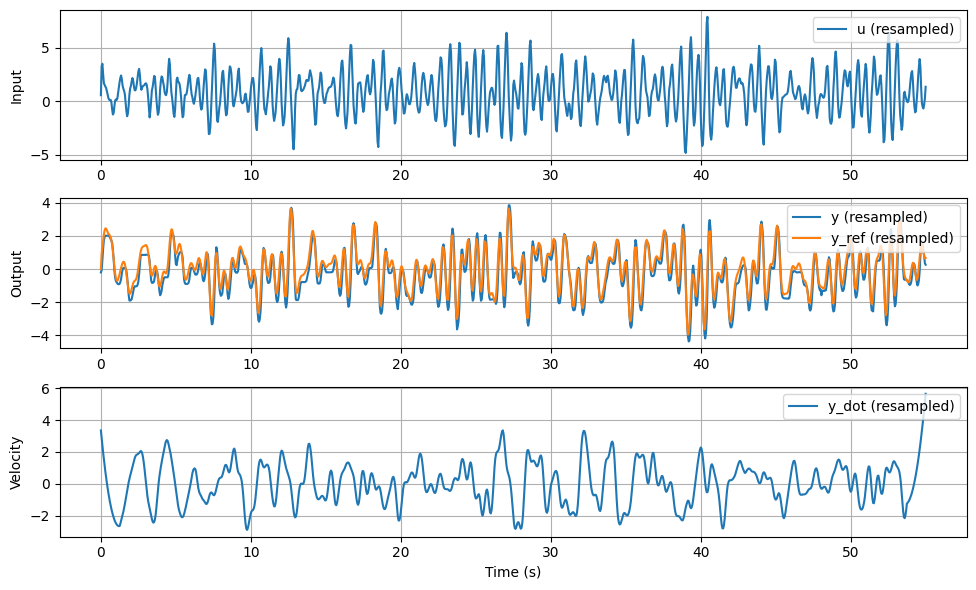

Dataset loaded: 1101 samples


In [3]:
# Load multisine_05 experiment with preprocessing
train_val = nod.load_experiment(
    "multisine_05",
    preprocess=True,
    plot=True,
    end_ref_tolerance=1e-8,
    y_dot_method="savgol",
)

# Unpack: y is raw output; y_ref is reference; y_dot from Savitzky-Golay
u, y, y_ref, y_dot = train_val
print(f"Dataset loaded: {len(u)} samples")

## 3. Model identification

In [4]:
# Model hyperparameters
ny_model = 3          # output lag order
nu_model = 3          # input lag order
poly_order_model = 3  # maximum polynomial degree
no_of_terms = 10      # number of terms selected by FROLS

# Instantiate and fit
narx_model = NARX(
    nu=nu_model,
    ny=ny_model,
    poly_order_l=poly_order_model,
    n_components=no_of_terms
)
narx_model.fit(u, y)

narx_model.print()


NARX model — selected terms and parameters
Max lag: 3  (ny=3, nu=3, l=3)
#    Term                                theta     ERR (%)
-------------------------------------------------------
1    y(k-1)                             1.1440   84.867250
2    y(k-2)                            -0.0171   12.723617
3    y(k-3)                            -0.1534    0.839038
4    u(k-1)                             0.2197    0.393913
5    constant                          -0.1618    0.770879
6    u(k-1)u(k-1)u(k-2)                 0.0015    0.058193
7    y(k-2)u(k-2)                       0.0124    0.036340
8    y(k-1)y(k-2)y(k-3)                 0.0022    0.008552
9    u(k-3)                            -0.0452    0.005659
10   y(k-2)u(k-2)u(k-2)                -0.0019    0.005557
-------------------------------------------------------
Total ERR explained:                 99.708998%


## 4. Free-run simulation

In [5]:
max_lag = narx_model._max_lag_internal_

# Free-run simulation on training data
y_fr_target = y[max_lag:]  # measured output (after initial conditions)
y_hat_fr = narx_model.predict(u, y_history_for_lags_or_osa=y[:max_lag], mode='FR')

# RMSE
rmse = np.sqrt(np.mean((y_fr_target - y_hat_fr) ** 2))
print(f"\nFree-run RMSE: {rmse:.6f}")

Starting Free-Run Simulation for 1098 steps...


FR Simulation:   0%|          | 0/1098 [00:00<?, ?step/s]


Free-run RMSE: 0.591285


## 5. Plot free-run simulation

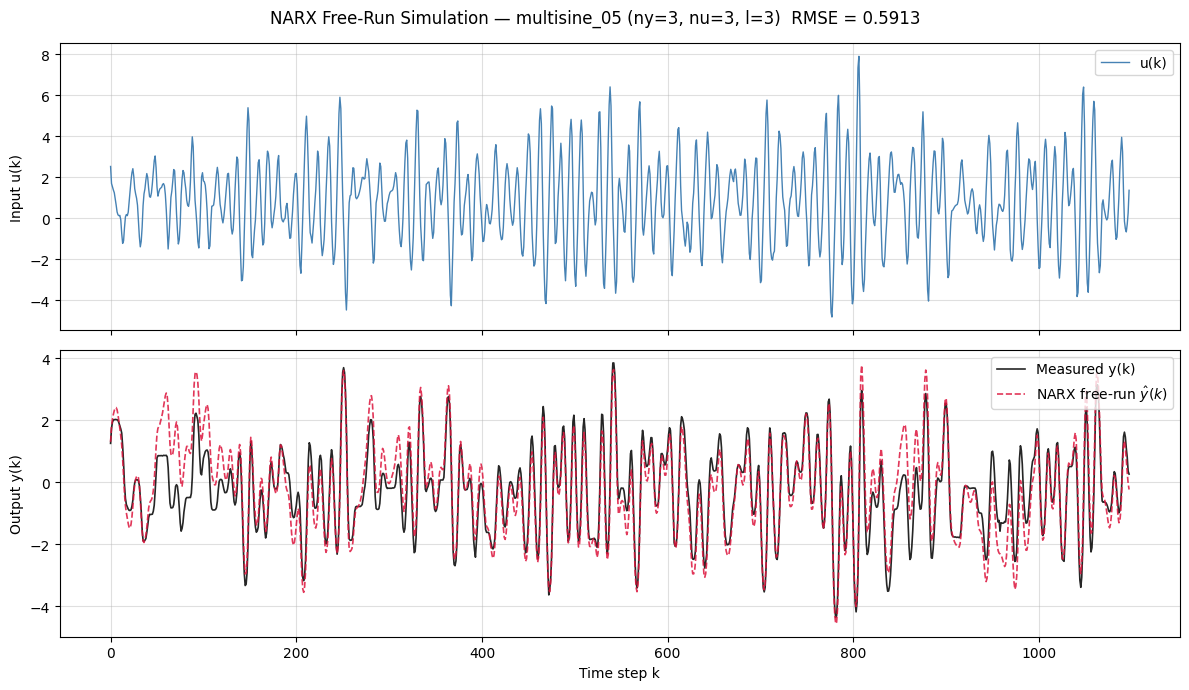

Figure saved as narx_fr_simulation.pdf


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Input signal ---
ax_u = axes[0]
time_fr = np.arange(len(y_fr_target))
ax_u.plot(time_fr, u[max_lag:], color='steelblue', linewidth=1.0, label='u(k)')
ax_u.set_ylabel('Input u(k)')
ax_u.legend(loc='upper right')
ax_u.grid(True, alpha=0.4)

# --- Output: measured vs. free-run simulated ---
ax_y = axes[1]
ax_y.plot(time_fr, y_fr_target, color='black', linewidth=1.2,
          label='Measured y(k)', alpha=0.85)
ax_y.plot(time_fr, y_hat_fr, color='crimson', linewidth=1.2,
          linestyle='--', label='NARX free-run $\\hat{y}(k)$', alpha=0.85)
ax_y.set_ylabel('Output y(k)')
ax_y.set_xlabel('Time step k')
ax_y.legend(loc='upper right')
ax_y.grid(True, alpha=0.4)

fig.suptitle(
    f'NARX Free-Run Simulation — multisine_05 '
    f'(ny={narx_model.ny}, nu={narx_model.nu}, l={narx_model.poly_order_l})  '
    f'RMSE = {rmse:.4f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('narx_fr_simulation.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as narx_fr_simulation.pdf")